In [1]:
import pandas as pd

# Load the dataset
file_path = "C:/Users/HP/Desktop/Github/MachineLearning/grad independent study/Combined Data.csv"
df = pd.read_csv(file_path)
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [2]:
# Remove the 'Unnamed' columns if they exist
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Display the cleaned DataFrame
print(df.head())

                                           statement   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3  I've shifted my focus to something else but I'...  Anxiety
4  I'm restless and restless, it's been a month n...  Anxiety


In [3]:
print(df.describe())

                statement  status
count               52681   53043
unique              51073       7
top     what do you mean?  Normal
freq                   22   16351


In [4]:
unique_status_values = df['status'].unique()
print(unique_status_values)

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


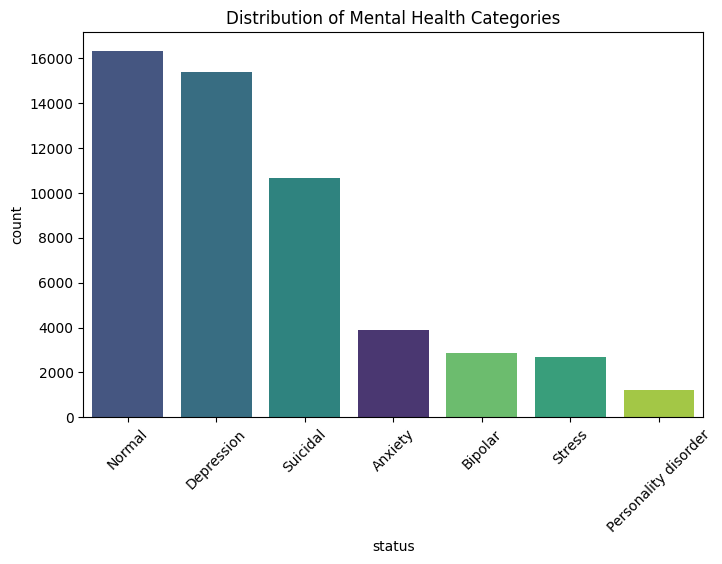


Category Distribution:
 status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

# Assigning 'hue' to the same variable as 'x' and disabling the legend
sns.countplot(data=df, x="status", order=df['status'].value_counts().index, hue="status", palette="viridis", legend=False)

plt.title("Distribution of Mental Health Categories")
plt.xticks(rotation=45)
plt.show()
print("\nCategory Distribution:\n", df['status'].value_counts())

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)


statement    362
status         0
dtype: int64


In [4]:
# Class distribution before filling
print(f'Class distribution before filling missing statement values: {df["status"].value_counts()}')

# Fill missing values in 'statement' column with the mode
#df['statement'].fillna(df['statement'].mode()[0], inplace=True)
df['statement'] = df['statement'].fillna(df['statement'].mode()[0])

# Class distribution after filling
print(f'Class distribution after filling missing statement values: {df["status"].value_counts()}')

Class distribution before filling missing statement values: status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64
Class distribution after filling missing statement values: status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [5]:
import re
import string

# Function to clean the text in the 'statement' column
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove leading/trailing whitespaces
    text = text.strip()
    return text

# Apply text cleaning to the 'statement' column
df['statement'] = df['statement'].apply(clean_text)

# Check the cleaned text
print(df['statement'].head())


0                                           oh my gosh
1    trouble sleeping confused mind restless heart ...
2    all wrong back off dear forward doubt stay in ...
3    ive shifted my focus to something else but im ...
4    im restless and restless its been a month now ...
Name: statement, dtype: object


In [6]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply the function to get sentiment polarity for each statement
df['sentiment'] = df['statement'].apply(get_sentiment)

# Check the sentiment column
print(df[['statement', 'sentiment']].head())


                                           statement  sentiment
0                                         oh my gosh     0.0000
1  trouble sleeping confused mind restless heart ...    -0.3000
2  all wrong back off dear forward doubt stay in ...    -0.2500
3  ive shifted my focus to something else but im ...     0.0000
4  im restless and restless its been a month now ...    -0.3125


In [7]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Apply VADER sentiment analysis
df['vader_sentiment'] = df['statement'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Display VADER sentiment results
print(df[['statement', 'vader_sentiment']].head())


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                           statement  vader_sentiment
0                                         oh my gosh           0.0000
1  trouble sleeping confused mind restless heart ...          -0.7269
2  all wrong back off dear forward doubt stay in ...          -0.7351
3  ive shifted my focus to something else but im ...          -0.4215
4  im restless and restless its been a month now ...          -0.4939


In [9]:
print(df[df['statement'].str.strip() == ''])
#while checking the flair get this message 2025-03-13 09:31:06,545 Warning: An empty Sentence was created! Are there empty strings in your dataset?
#

      statement    status  sentiment  vader_sentiment
8532             Suicidal        0.0              0.0
10342            Suicidal        0.0              0.0
32100              Normal        0.0              0.0


In [10]:
mode_value = df['statement'].mode()[0]
print(f"Mode Value: '{mode_value}'")  # Check if it's a valid sentence



Mode Value: 'what do you mean'


In [11]:
df['statement'].replace(r'^\s*$', 'No text available', regex=True, inplace=True)


In [12]:
print(df[df['statement'].str.strip() == ''])  # Should return an empty dataframe


Empty DataFrame
Columns: [statement, status, sentiment, vader_sentiment]
Index: []


In [ ]:

from flair.models import TextClassifier
from flair.data import Sentence

# Load the pre-trained sentiment analysis model
classifier = TextClassifier.load('sentiment')

# Function to get sentiment score using Flair
def get_flair_sentiment(text):
    sentence = Sentence(text)
    classifier.predict(sentence)
    return sentence.labels[0].score if sentence.labels else None

df['flair_sentiment'] = df['statement'].apply(get_flair_sentiment)

# Display Flair sentiment results
print(df[['statement', 'flair_sentiment']].head())


In [ ]:
from transformers import pipeline

# Load the sentiment analysis pipeline
sentiment_pipeline = pipeline("sentiment-analysis")

# Apply the sentiment analysis model
df['bert_sentiment'] = df['statement'].apply(lambda x: sentiment_pipeline(x)[0]['score'])

# Display BERT sentiment results
print(df[['statement', 'bert_sentiment']].head())


In [ ]:
print(df[['sentiment', 'vader_sentiment', 'flair_sentiment', 'bert_sentiment']].corr())


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['sentiment'], color='blue', label='TextBlob', kde=True)
sns.histplot(df['vader_sentiment'], color='red', label='VADER', kde=True)
sns.histplot(df['flair_sentiment'], color='green', label='Flair', kde=True)
sns.histplot(df['bert_sentiment'], color='purple', label='BERT', kde=True)
plt.legend()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Prepare Features and Target
X = df[['statement', 'sentiment']]  
y = df['status']  

# 2. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Apply CountVectorizer and TF-IDF Vectorizer on 'statement'
count_vectorizer = CountVectorizer(stop_words='english')
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# CountVectorizer
X_train_count = count_vectorizer.fit_transform(X_train['statement'])
X_test_count = count_vectorizer.transform(X_test['statement'])

# TF-IDF Vectorizer
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['statement'])
X_test_tfidf = tfidf_vectorizer.transform(X_test['statement'])

# 4. Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)

# For CountVectorizer features
X_train_count_smote, y_train_smote = smote.fit_resample(X_train_count, y_train)

# For TF-IDF features
X_train_tfidf_smote, y_train_tfidf_smote = smote.fit_resample(X_train_tfidf, y_train)

# 5. Cross-validation using CountVectorizer features
clf = RandomForestClassifier(random_state=42)
count_cv_scores = cross_val_score(clf, X_train_count_smote, y_train_smote, cv=5, scoring='accuracy')


# 6. Display Results
print(f'CountVectorizer cross-validation scores: {count_cv_scores}')
print(f'Mean accuracy with CountVectorizer: {np.mean(count_cv_scores)}')



In [ ]:
# Cross-validation using TF-IDF features
tfidf_cv_scores = cross_val_score(clf, X_train_tfidf_smote, y_train_tfidf_smote, cv=5, scoring='accuracy')

print(f'TF-IDF cross-validation scores: {tfidf_cv_scores}')
print(f'Mean accuracy with TF-IDF: {np.mean(tfidf_cv_scores)}')




In [ ]:
# 7. Choose the best method (based on the cross-validation results)
if np.mean(count_cv_scores) > np.mean(tfidf_cv_scores):
    print('Using CountVectorizer for final model.')
    X_train_final = X_train_count_smote
    X_test_final = X_test_count
else:
    print('Using TF-IDF for final model.')
    X_train_final = X_train_tfidf_smote
    X_test_final = X_test_tfidf


In [ ]:
# 8. Train the model with the chosen vectorization method
clf.fit(X_train_final, y_train_smote)

# 9. Make predictions and evaluate the model
y_pred = clf.predict(X_test_final)
acc_smote = accuracy_score(y_test, y_pred)

print(f'Accuracy with SMOTE: {acc_smote}')